# Student Performance Indicator

In [1]:
## Lifecycle of Machine Learning Project
### Understanding the Problem Statement
### Data Collection
### Data checks to perform
### Exploratory Data Analysis
### Data preprocessing
### Model Training
### Choose best model

## Problem Statement

### This project is to understand how student performance i.e. test score is affected by other variables such as Gender, Ethnicity,
### Parental level of education, lunch and test preparation course

### Importing Libraries

In [40]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

### Importing CSV Data as Dataframe

In [4]:
df=pd.read_csv('data/stud.csv')

In [5]:
df.head(5)

,gender,race_ethnicity,parental_level_of_education,lunch,test_preparation_course,math_score,reading_score,writing_score
0,female,group B,bachelor's degree,standard,none,72,72,74
1,female,group C,some college,standard,completed,69,90,88
2,female,group B,master's degree,standard,none,90,95,93
3,male,group A,associate's degree,free/reduced,none,47,57,44
4,male,group C,some college,standard,none,76,78,75


In [6]:
df.shape

(1000, 8)

#### Data checks to perform
#### Check missing values
#### Check data type
#### Check the number of unique values of each column.
#### Check statistics of dataset.
#### Check various categories present in different categorical columns.

In [7]:
#checking missing values
df.isna().sum()

gender                         0
race_ethnicity                 0
parental_level_of_education    0
lunch                          0
test_preparation_course        0
math_score                     0
reading_score                  0
writing_score                  0
dtype: int64

In [8]:
# checking duplicate values in data
df.duplicated().sum()

np.int64(0)

In [9]:
# checking for data type
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 8 columns):
 #   Column                       Non-Null Count  Dtype
---  ------                       --------------  -----
 0   gender                       1000 non-null   str  
 1   race_ethnicity               1000 non-null   str  
 2   parental_level_of_education  1000 non-null   str  
 3   lunch                        1000 non-null   str  
 4   test_preparation_course      1000 non-null   str  
 5   math_score                   1000 non-null   int64
 6   reading_score                1000 non-null   int64
 7   writing_score                1000 non-null   int64
dtypes: int64(3), str(5)
memory usage: 62.6 KB


In [10]:
df.nunique()

gender                          2
race_ethnicity                  5
parental_level_of_education     6
lunch                           2
test_preparation_course         2
math_score                     81
reading_score                  72
writing_score                  77
dtype: int64

In [11]:
df.describe()

,math_score,reading_score,writing_score
count,1000.00000,1000.000000,1000.000000
mean,66.08900,69.169000,68.054000
std,15.16308,14.600192,15.195657
min,0.00000,17.000000,10.000000
25%,57.00000,59.000000,57.750000
50%,66.00000,70.000000,69.000000
75%,77.00000,79.000000,79.000000
max,100.00000,100.000000,100.000000


In [12]:
print("Categories in gender variable", end=" ")
print(df['gender'].unique())

print("Categories in race_ethnicity variable", end=" ")
print(df['race_ethnicity'].unique())

print("Categories in parental_level_of_education variable", end=" ")
print(df['parental_level_of_education'].unique())

print("Categories in lunch variable", end=" ")
print(df['lunch'].unique())

print("Categories in test_preparation_course variable", end=" ")
print(df['test_preparation_course'].unique())

Categories in gender variable <StringArray>
['female', 'male']
Length: 2, dtype: str
Categories in race_ethnicity variable <StringArray>
['group B', 'group C', 'group A', 'group D', 'group E']
Length: 5, dtype: str
Categories in parental_level_of_education variable <StringArray>
[ 'bachelor's degree',       'some college',    'master's degree',
 'associate's degree',        'high school',   'some high school']
Length: 6, dtype: str
Categories in lunch variable <StringArray>
['standard', 'free/reduced']
Length: 2, dtype: str
Categories in test_preparation_course variable <StringArray>
['none', 'completed']
Length: 2, dtype: str


In [24]:
# Defining numerical and categorical columns
numeric_features= [feature for feature in df.columns if df[feature].dtype =='int64']
categorical_features= [feature for feature in df.columns if df[feature].dtype =='str']

In [26]:
print('we have {} numerical features as: {}'.format(len(numeric_features), numeric_features))
print('we have {} categorical features as: {}'.format(len(categorical_features), categorical_features))

we have 3 numerical features as: ['math_score', 'reading_score', 'writing_score']
we have 5 categorical features as: ['gender', 'race_ethnicity', 'parental_level_of_education', 'lunch', 'test_preparation_course']


### Adding columns for total score and average

In [27]:
df['total_score']=df['math_score']+df['reading_score']+df['writing_score']
df['average_score']=df['total_score']/3
df.head(3)

,gender,race_ethnicity,parental_level_of_education,lunch,test_preparation_course,math_score,reading_score,writing_score,total_score,average_score
0,female,group B,bachelor's degree,standard,none,72,72,74,218,72.666667
1,female,group C,some college,standard,completed,69,90,88,247,82.333333
2,female,group B,master's degree,standard,none,90,95,93,278,92.666667


In [37]:
# Students with full score
reading_full= df[df['reading_score']==100]['reading_score'].count()
writing_full=df[df['writing_score']==100]['reading_score'].count()
math_full= df[df['math_score']==100]['reading_score'].count()

print(f'Number of students with full marks in maths: {math_full}')
print(f'Number of students with full marks in Writting: {writing_full}')
print(f'Number of students with full marks in Reading: {reading_full}')

Number of students with full marks in maths: 7
Number of students with full marks in Writting: 14
Number of students with full marks in Reading: 17


In [39]:
# Students with less score
reading_less= df[df['reading_score']<=20]['reading_score'].count()
writing_less=df[df['writing_score']<=20]['reading_score'].count()
math_less= df[df['math_score']<=20]['reading_score'].count()

print(f'Number of students with less marks in maths: {math_less}')
print(f'Number of students with less marks in Writting: {writing_less}')
print(f'Number of students with less marks in Reading: {reading_less}')

Number of students with less marks in maths: 4
Number of students with less marks in Writting: 3
Number of students with less marks in Reading: 1


#### Visualizing average score distribution

#### Histogram and KDE (Kernel Distribution Function)

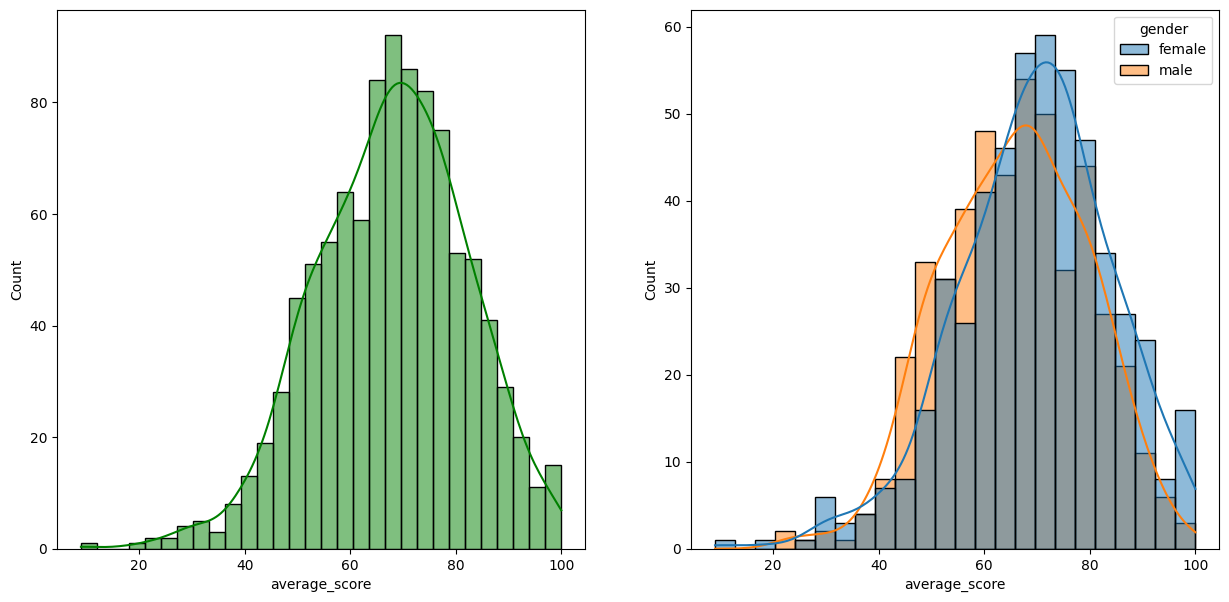

In [ ]:
# Average score distribution based on gender
fig, axs= plt.subplots(1,2, figsize=(15,7))
plt.subplot(1,2,1)
sns.histplot(data=df, x='average_score', bins=30, kde=True, color='g')

plt.subplot(1,2,2)
sns.histplot(data=df, x='average_score', kde=True, hue='gender')

plt.show()

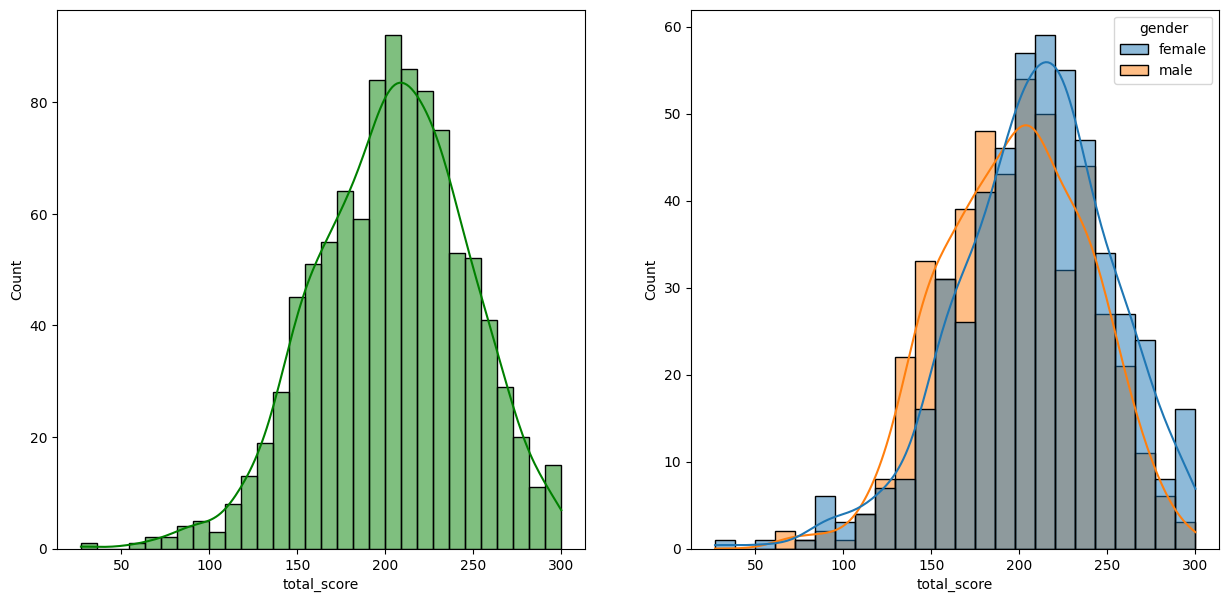

In [45]:
# total_score distribution based on gender.
fig, axs = plt.subplots(1, 2, figsize=(15, 7))
plt.subplot(121)
sns.histplot(data=df,x='total_score',bins=30,kde=True,color='g')
plt.subplot(122)
sns.histplot(data=df,x='total_score',kde=True,hue='gender')
plt.show()

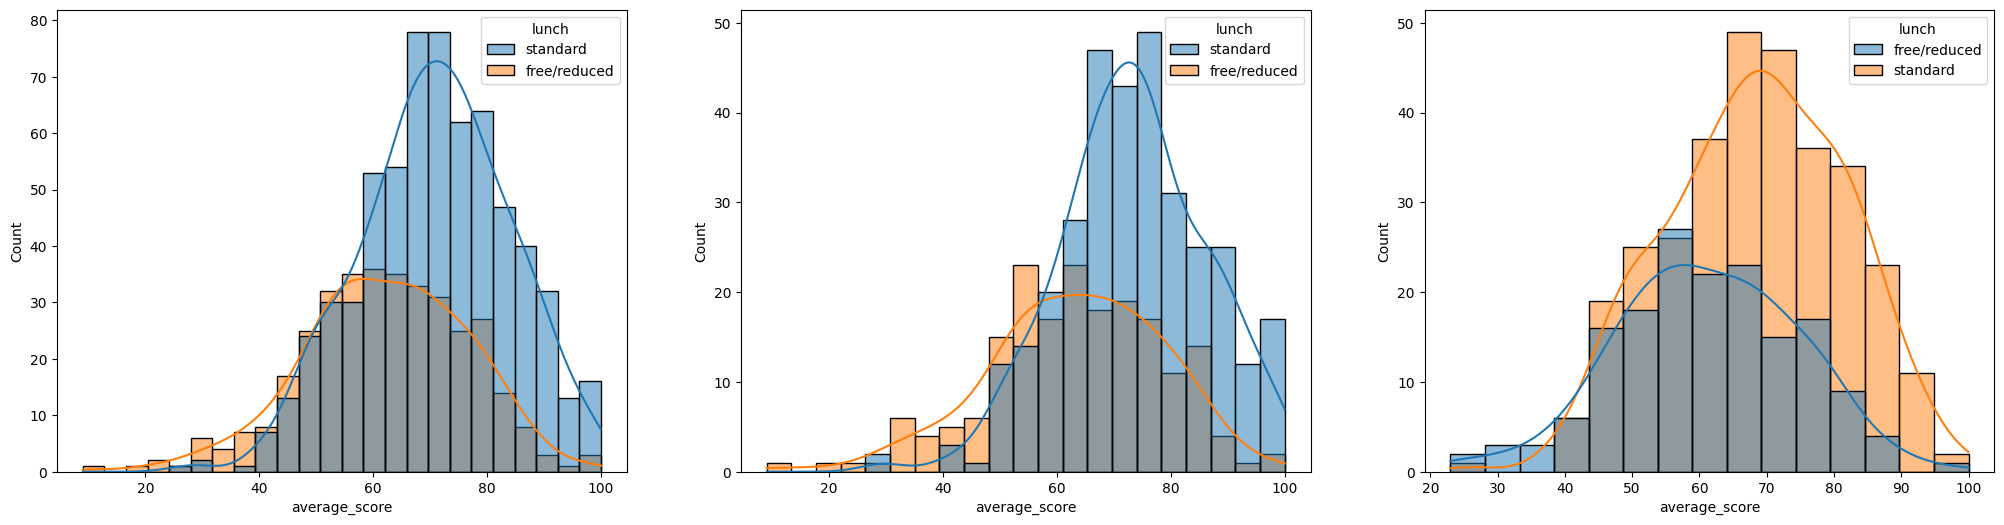

In [48]:
## Score distribution based on gender.

plt.subplots(1,3,figsize=(25,6))
plt.subplot(131)
sns.histplot(data=df,x='average_score',kde=True,hue='lunch')

plt.subplot(132)
sns.histplot(data=df[df.gender=='female'],x='average_score',kde=True,hue='lunch')

plt.subplot(133)
sns.histplot(data=df[df.gender=='male'],x='average_score',kde=True,hue='lunch')
plt.show()